# Welcome to lab_kmeans! 🎓

In this lab, you will continue your exploration of the GPA dataset by doing some k-means clustering! 

A few tips to remember:

- **You are not alone on your journey in learning programming!** You have your lab TA, your CAs, your lab group, and the professors (Prof. Wade and Prof. Karle), who are all here to help you out!
- If you find yourself stuck for more than a few minutes, ask a neighbor or course staff for help! When you are giving help to your neighbor, explain the **idea and approach** to the problem without sharing the answer itself so they can have the same ***ah-hah*** moment!
- We are here to help you! Don't feel embarrassed or shy to ask us for help!

Let's get started!

In [ ]:
# Meet your CAs and TA if you haven't already!
# ...first name is enough, we'll know who they are! :)
ta_name = "Kunlun"
ca1_name = "Caroline"
ca2_name = "Emily"
ca3_name = ""


# Say hello to each other!
# - Groups of 3 are ideal :)
# - However, groups of 2 or 4 are fine too!
#
# Question of the Day (QOTD) to Ask Your Group: "What's your favorite RSO on campus?"
partner1_name = "Xinmeng"
partner1_netid = "xinmeng7"
partner1_day = "Math club"

partner2_name = ""
partner2_netid = ""
partner2_day = ""

partner3_name = ""
partner3_netid = ""
partner3_day = ""

<hr style="color: #DD3403;">

# Part 1: Exploring GPA, Again

In **lab_gpa**, you explored the dataset that Professor Wade uses to make the GPA visualizations and found the average GPA for each subject! In this lab, you'll continue analyzing the subjects by clustering them. The columns we are interested in clustering with are the
- Average GPA
- Average course number
- Average number of students

for each subject.

As before, the most recent version of the GPA dataset is available here:
```
https://waf.cs.illinois.edu/discovery/gpa.csv
```

Use Python to load this dataset into a DataFrame called `df`:

In [59]:
import pandas as pd
df=pd.read_csv("https://waf.cs.illinois.edu/discovery/gpa.csv")
df

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C+,C,C-,D+,D,D-,F,W,Primary Instructor,Students
0,2024,Winter,2024-wi,ADV,150,Introduction to Advertising,ONL,22,18,1,...,0,0,0,0,0,0,0,0,"Hall, Steven R",42
1,2024,Winter,2024-wi,AFRO,100,Intro to African American St,ONL,5,8,6,...,0,1,1,0,0,0,1,0,"McMillion, Desiree Y",25
2,2024,Winter,2024-wi,ASTR,330,Extraterrestrial Life,ONL,1,16,8,...,1,0,2,0,1,0,0,0,"Dunne, Bryan C",37
3,2024,Winter,2024-wi,ATMS,120,Severe and Hazardous Weather,ONL,3,16,3,...,2,2,1,1,1,1,2,0,"Choate, Jessica J",46
4,2024,Winter,2024-wi,BADM,275,Operations Management,ONL,0,49,17,...,2,3,0,0,0,0,0,0,"Hu, Junqi",81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69107,2010,Summer,2010-su,STAT,410,Statistics and Probability II,LEC,5,10,2,...,0,1,3,0,0,0,2,1,"Stepanov, Alexei G",31
69108,2010,Summer,2010-su,STAT,440,Statistical Data Management,LEC,4,12,8,...,0,0,0,0,0,0,0,0,"Unger, David",28
69109,2010,Summer,2010-su,TAM,212,Introductory Dynamics,LEC,0,1,3,...,5,1,1,0,2,0,1,0,"Morgan, William T",28
69110,2010,Summer,2010-su,TAM,251,Introductory Solid Mechanics,LCD,1,2,2,...,3,3,2,0,0,1,1,0,"Ott-Monsivais, Stephanie",21


### 🔬 Test Case Checkpoint 🔬

In [60]:
## == CHECKPOINT TEST CASES ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any errors, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert(len(df) == 69112), "This is not the GPA dataset you're looking for."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 1.1: Average GPA by Subject

Let's get back to where we were in **Part 2 of lab_gpa** and calculate the Average GPA by Subject!

Create a dataframe `df_subject` with the column `"Average GPA"` (feel free to reference your lab_gpa code). To help, we have provided the `calculateAverageGPA` function that you created in Part 1. Remember that we first need to sum the values for each subject since the average GPA should be weighted.

In [61]:
# This function is provided for you
def calculateAverageGPA(row):
    average_gpa = (row['A+'] * 4 + row['A'] * 4 + row['A-'] * 3.67 
                    + row['B+'] * 3.33 + row['B'] * 3 + row['B-'] * 2.67 
                    + row['C+'] * 2.33 + row['C'] * 2 + row['C-'] * 1.67 
                    + row['D+'] * 1.33 + row['D'] * 1 + row['D-'] * 0.67 + row['F'] * 0) / row['Students']
    return average_gpa

In [62]:
# Create df_subject with the `Average GPA` column
df_subject = df.groupby("Subject").agg("sum",numeric_only = True).reset_index()
df_subject["Average GPA"] = calculateAverageGPA(df_subject)
df_subject

,Subject,Year,Number,A+,A,A-,B+,B,B-,C+,C,C-,D+,D,D-,F,W,Students,Average GPA
0,AAS,494134,30940,1050,2829,1053,658,644,308,165,169,70,39,44,26,132,26,7187,3.517274
1,ABE,334747,55405,584,3332,912,830,987,260,148,194,50,21,52,9,74,19,7453,3.533133
2,ACCY,5737609,1079894,15871,36922,21865,19613,18654,7728,3912,3196,1579,439,876,294,953,363,131902,3.435311
3,ACE,2290983,320492,8769,19270,6845,5559,9093,3328,2156,3124,1032,497,882,294,993,152,61842,3.342199
4,ACES,383227,22012,1612,2095,393,197,316,87,92,94,40,25,34,19,94,10,5098,3.659425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,128783,1483,4977,2508,1437,1509,591,317,339,161,51,103,71,248,39,13795,3.467809
170,VB,8040,2489,0,212,6,6,120,1,0,40,0,0,2,0,0,0,387,3.448760
171,VCM,110864,34284,547,1687,35,63,1087,20,23,349,1,1,40,0,7,2,3860,3.467158
172,VM,258207,78366,0,2879,8,0,7981,1,0,4725,0,0,554,0,21,10,16169,2.813719


In [63]:
## == TEST CASES for Puzzle 1.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( 'df_subject' in vars() ), "Make sure your DataFrame grouped by 'Subject' is named 'df_subject'." 
assert( (len(df_subject.columns) == 24) | (len(df_subject.columns) == 19)), "Make sure your DataFrame has the appropriate number of columns! Remember to use .reset_index()!"
assert( len(df_subject) == 174 ), "Make sure you are grouping by 'Subject'. There are 174 Subjects in our original `df`, so the length of `df_subject` should be 174."
assert( math.isclose(df_subject.Students.mean(), 23685.287356321838) ), "Double-check that you are aggregating your df_subject correctly."

assert( "Average GPA" in df_subject.columns), "Make sure your column is still named 'Average GPA'."
assert( math.isclose(df_subject['Average GPA'].mean(), 3.474516261357219520825) ), "Your calculation of the Average GPA by Subject is incorrect."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 1.2: Average Course Number and Students

Now let's create the other two columns we are interested in. Unlike the average GPA, we will just use the straight average (no weighting) of each course in the subject. Call these columns `"Average Number"` and `"Average Students"`.

Since we are not weighting, we don't want to aggregate by sum this time. You will need to create another dataframe that aggregates in a different way, then transfer the column(s) to `df_subject`.

*Hint: We did something similar in lab_plots Part 2.5 when we added the `"Average Salary"` column to `agg_count_df`. Feel free to add more code cells!*

In [64]:
# Add the "Average Number" and "Average Students" columns to `df_subject`
agg_count_df = df.groupby("Subject").agg("count").reset_index()
df_subject["Average Number"] = df_subject.Number/agg_count_df.Year
df_subject["Average Students"] = df_subject.Students/agg_count_df.Year
df_subject

,Subject,Year,Number,A+,A,A-,B+,B,B-,C+,...,C-,D+,D,D-,F,W,Students,Average GPA,Average Number,Average Students
0,AAS,494134,30940,1050,2829,1053,658,644,308,165,...,70,39,44,26,132,26,7187,3.517274,126.285714,29.334694
1,ABE,334747,55405,584,3332,912,830,987,260,148,...,50,21,52,9,74,19,7453,3.533133,333.765060,44.897590
2,ACCY,5737609,1079894,15871,36922,21865,19613,18654,7728,3912,...,1579,439,876,294,953,363,131902,3.435311,379.576098,46.362742
3,ACE,2290983,320492,8769,19270,6845,5559,9093,3328,2156,...,1032,497,882,294,993,152,61842,3.342199,282.123239,54.438380
4,ACES,383227,22012,1612,2095,393,197,316,87,92,...,40,25,34,19,94,10,5098,3.659425,115.852632,26.831579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,128783,1483,4977,2508,1437,1509,591,317,...,161,51,103,71,248,39,13795,3.467809,355.754144,38.107735
170,VB,8040,2489,0,212,6,6,120,1,0,...,0,0,2,0,0,0,387,3.448760,622.250000,96.750000
171,VCM,110864,34284,547,1687,35,63,1087,20,23,...,1,1,40,0,7,2,3860,3.467158,623.345455,70.181818
172,VM,258207,78366,0,2879,8,0,7981,1,0,...,0,0,554,0,21,10,16169,2.813719,612.234375,126.320312


In [65]:
## == TEST CASES for Puzzle 1.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert "Average Number" in df_subject.columns, "df_subject does not have an `Average Number` column"
assert "Average Students" in df_subject.columns, "df_subject does not have an `Average Students` column" 

assert not math.isclose(df_subject["Average Number"].mean(), 117023.86781609195) \
       and not math.isclose(df_subject["Average Number"].mean(), 397.1954022988506), "Make sure you are aggregating correctly!"
assert not math.isclose(df_subject["Average Students"].mean(), 23685.287356321838) \
       and not math.isclose(df_subject["Average Students"].mean(), 397.1954022988506), "Make sure you are aggregating correctly!"

assert math.isclose(df_subject["Average Number"].std(), 123.65903947868387), "The `Average Number` column is incorrect"
assert math.isclose(df_subject["Average Students"].std(), 26.050087425482868), "The `Average Students` column is incorrect"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 1.3: Standardizing

For k-means clustering, it is important that the variables are on the same scale so they have an equal impact on the clustering. Currently, `"Average GPA"` is less than 4, `"Average Number"` is in the hundreds, and `"Average Students"` is usually in the double digits.

To account for this, we will **standardize** each column by subtracting the mean of the column and dividing by the standard deviation of the column, just like we do to calculate the z-score!

We have given you starter code to create a `df_subject_standardized` dataframe that will contain the standardized data. From here, add the standardized version of the three columns from `df_subject` (use the same names).

It may be helpful to create additional variables or code cells!

In [66]:
# Add the three standardized columns 
df_subject_standardized = df_subject[["Subject"]].copy() # start off with the "Subject" column

df_subject_standardized["Average GPA"] = (df_subject["Average GPA"]- df_subject["Average GPA"].mean())/df_subject["Average GPA"].std()
df_subject_standardized["Average Number"] = (df_subject["Average Number"]- df_subject["Average Number"].mean())/df_subject["Average Number"].std()
df_subject_standardized["Average Students"] = (df_subject["Average Students"]- df_subject["Average Students"].mean())/df_subject["Average Students"].std()

In [67]:
## == TEST CASES for Puzzle 1.3 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert set(df_subject_standardized.columns) == {"Subject", "Average GPA", "Average Number", "Average Students"}, "`df_subject_standardized` does not have the right columns"

for column in ["Average GPA", "Average Number", "Average Students"]:
    assert math.isclose(df_subject_standardized[column].mean(), 0, abs_tol = 1e-14), f"The {column} column was not standardized correctly"
    assert math.isclose(df_subject_standardized[column].std(), 1, abs_tol = 1e-14), f"The {column} column was not standardized correctly"

assert math.isclose(df_subject_standardized["Average GPA"].median(), -0.024965041712592274), "The Average GPA column was not standardized correctly"
assert math.isclose(df_subject_standardized["Average Number"].median(), -0.1485000624162024), "The Average Number column was not standardized correctly"
assert math.isclose(df_subject_standardized["Average Students"].median(), -0.3330014049723421), "The Average Students column was not standardized correctly"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


# Part 2: K-Means Clustering (K=2)


If you **do not** have the `scikit-learn` library installed, try running any one of following commands in your **terminal** until successful installation:
- `python3 -m pip install scikit-learn`
- `pip install scikit-learn`
- `pip3 install scikit-learn`
- `py -m pip install scikit-learn`

If you are still having import errors trying these commands, **let your lab CAs and TAs know**! They will help you through the installation process. 

### Part 2.1: Two-Cluster Model

It's time to start clustering! In the cells below, we will create a new k-means model named `kmeans` that contains just **two (2) clusters**.

First, create a list called `ind` that contains the the names of the columns we are using to fit the model. Then, create and fit the model. Finally, predict the clusters for each subject.

You should store the predictions in the column `"Cluster"` in `df_subject`. We are using this instead of `df_subject_standardized` so that we can interpret the result on the original scale -- the standardized scale only matters when fitting the model.

In [68]:
# Create a list of the names of the columns we are using to fit the model

ind = ["Average GPA", "Average Number", "Average Students"]

In [69]:
# import the KMeans function
from sklearn.cluster import KMeans

# Create, fit, and predict with the KMeans model
kmeans = KMeans(2)
kmeans.fit(df_subject_standardized[ind])

df_subject["Cluster"] = kmeans.predict(df_subject_standardized[ind])
df_subject

,Subject,Year,Number,A+,A,A-,B+,B,B-,C+,...,D+,D,D-,F,W,Students,Average GPA,Average Number,Average Students,Cluster
0,AAS,494134,30940,1050,2829,1053,658,644,308,165,...,39,44,26,132,26,7187,3.517274,126.285714,29.334694,0
1,ABE,334747,55405,584,3332,912,830,987,260,148,...,21,52,9,74,19,7453,3.533133,333.765060,44.897590,1
2,ACCY,5737609,1079894,15871,36922,21865,19613,18654,7728,3912,...,439,876,294,953,363,131902,3.435311,379.576098,46.362742,1
3,ACE,2290983,320492,8769,19270,6845,5559,9093,3328,2156,...,497,882,294,993,152,61842,3.342199,282.123239,54.438380,0
4,ACES,383227,22012,1612,2095,393,197,316,87,92,...,25,34,19,94,10,5098,3.659425,115.852632,26.831579,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,128783,1483,4977,2508,1437,1509,591,317,...,51,103,71,248,39,13795,3.467809,355.754144,38.107735,1
170,VB,8040,2489,0,212,6,6,120,1,0,...,0,2,0,0,0,387,3.448760,622.250000,96.750000,1
171,VCM,110864,34284,547,1687,35,63,1087,20,23,...,1,40,0,7,2,3860,3.467158,623.345455,70.181818,1
172,VM,258207,78366,0,2879,8,0,7981,1,0,...,0,554,0,21,10,16169,2.813719,612.234375,126.320312,1


In [70]:
## == TEST CASES for Puzzle 2.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert 'ind' in vars(), "Make sure to create the variable `ind`"
assert type(ind) is list, "Make sure that `ind` is a list of strings"
assert set(ind) == {"Average GPA", "Average Number", "Average Students"}

assert 'kmeans' in vars(), "Make sure to create the variable `kmeans`"
assert kmeans.n_clusters == 2, "Make sure to use 2 clusters"
assert set(kmeans.feature_names_in_) == set(ind), "Make sure to use the right columns to fit the model"

assert "Cluster" in df_subject.columns, "Make sure to add the column \"Cluster\" to `df_subject`"
assert kmeans.cluster_centers_.mean() < 1, "Make sure you are using the right dataframe to fit the model"
assert df_subject["Cluster"].nunique() == 2, "Make sure you are using the right dataframe to predict the model"
assert all(df_subject["Cluster"] == kmeans.labels_), "Looks like your \"Cluster\" column is wrong"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 2.2: Visualizing the Clusters

Creating a `"Cluster"` column is nice, but it's difficult to tell what exactly this means in terms of the data. A great way to solve this is to use a visualization!

The library Seaborn is a great way to easily create features plots with extra features. We demonstrated using it to create a regression line in **lab_regression** Part 2.2, and now we're going to use it to color the points by cluster!

Here's the relevant parameters we will use in the function `sns.scatterplot`:
- `data`: The dataframe containg the data we are using to plot
- `x` and `y`: The names of the columns we are plotting on each axis (same as for `df.plot.scatterplot`)
- `hue`: The name of the column we want to use to color the points
- `palette`: The name of the color scheme used to color the points. We have provided an example of a palette you can use.

Complete the code below to create a scatterplot of the **average course number** and **average number of students**, colored by cluster. Make sure that the axes are on the original scale (not standardized) and replace the ellipsis in `plt.title(...)` with an appropriate title for the plot.

If you're feeling artsy, you can change the parameter `palette` to the name of another of Seaborn's supported color schemes: https://www.practicalpythonfordatascience.com/ap_seaborn_palette!

Text(0.5, 1.0, 'Relationship between Avg number of Students and Avg Number')

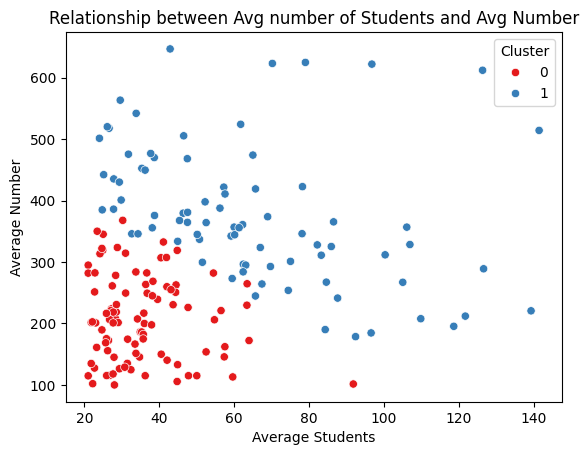

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data = df_subject,
    x = "Average Students",
    y = "Average Number",
    hue = "Cluster",
    palette = "Set1"
)
plt.title("Relationship between Avg number of Students and Avg Number")

# Part 3: K-Means Clustering (K=3)

How can we tell if our model is good? What if a different number of clusters would have been more appropriate?

One way to evaluate is to consider how close the points are to the center of their cluster (centroid). A metric called **inertia** measures the squared distance between each point and its centroid, then adds them together for all points. A high inertia means that the points tend to be far away from their centroids, while a low interia means that the points tend to be close to their centroids.

Luckily, the model does this calculation for us when fitting! We can find the inertia for by putting `.inertia_` after the model as shown below:

### Part 3.1: Elbow Plot

In [72]:
kmeans.inertia_

383.38878320128936

As you might expect, inertia decreases as the number of clusters increases since more cluster means each point can be assigned to a closer centroid. However, lots of clusters might make the model difficult to interpret and visualize. We want to pick a number of clusters that results in a low inertia without being `k` too high.

To achieve this goal, we need to calculate the inertia for multiple cluster numbers. We have provided the code for a function `calculate_inertia` that takes a parameter `k` (the number of clusters) and returns the model's inertia for that `k`.

In [73]:
# This code is provided for you, no need to change anything
def calculate_inertia(k):
    model = KMeans(k)
    model.fit(df_subject_standardized[ind])
    return model.inertia_ # Since inertia is calculated in the fit step, there is no need to predict!

It's easiest to visualize the inertias with an a type of graph called an **elbow plot**, where the inertia is on the y-axis and the number of clusters is on the x-axis.

To create it, have provided code to create a dataframe that stores the number of clusters and the inertia for each `k` between 1 and 8.

In [74]:
# This code is provided for you, no need to change anything
data = []
for i in range(8):
    k = i + 1 # add 1 since range(8) gives 0 through 7
    inertia = calculate_inertia(k)
    d = {"k": k, "inertia": inertia}
    data.append(d)
df_inertia = pd.DataFrame(data)
df_inertia

,k,inertia
0,1,519.000000
1,2,374.515316
2,3,272.893987
3,4,217.911166
4,5,189.455703
5,6,174.173830
6,7,144.455114
7,8,131.470428


Now we create the elbow plot by making a **line plot** with the inertia on the y-axis and the number of clusters on the x-axis.

<Axes: title={'center': 'Elbow Plot'}, xlabel='k'>

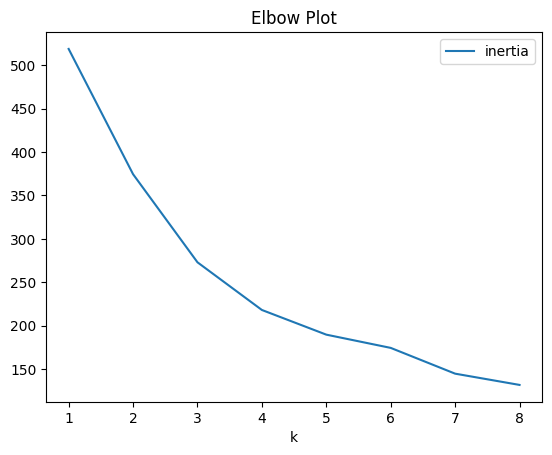

In [75]:
# This code is provided for you, no need to change anything
df_inertia.plot.line(x = "k", y = "inertia", title = "Elbow Plot")

Notice that the inertia decreases as the number of clusters increases. We should choose `k` where there is the sharpest "elbow" (hence the plot name), which means that the slope starts to level out the most.

Since k-means is random, your plot will vary if you run the above two cells again. However, most of the time we can see that `k=3` looks promising: there is not as much inertia to be lost going from 3 to 4 as from 2 to 3. Note that this process is a bit subjective, and `k=3` is not the only reasonable choice.

### Part 3.2: Three-Cluster Model
Now that we've chosen our number of clusters, we can cluster one last time!

Just like in Part 2.1, create and fit the model, then predict the clusters for each subject. Make sure to use 3 clusters this time!

As before, store the predictions in the column `"Cluster"` in `df_subject` (it is okay to replace the values from the 2-cluster model).

In [76]:
# Fit the model with three clusters
kmeans = KMeans(3)
kmeans.fit(df_subject_standardized[ind])

df_subject["Cluster"] = kmeans.predict(df_subject_standardized[ind])
df_subject

,Subject,Year,Number,A+,A,A-,B+,B,B-,C+,...,D+,D,D-,F,W,Students,Average GPA,Average Number,Average Students,Cluster
0,AAS,494134,30940,1050,2829,1053,658,644,308,165,...,39,44,26,132,26,7187,3.517274,126.285714,29.334694,1
1,ABE,334747,55405,584,3332,912,830,987,260,148,...,21,52,9,74,19,7453,3.533133,333.765060,44.897590,2
2,ACCY,5737609,1079894,15871,36922,21865,19613,18654,7728,3912,...,439,876,294,953,363,131902,3.435311,379.576098,46.362742,2
3,ACE,2290983,320492,8769,19270,6845,5559,9093,3328,2156,...,497,882,294,993,152,61842,3.342199,282.123239,54.438380,1
4,ACES,383227,22012,1612,2095,393,197,316,87,92,...,25,34,19,94,10,5098,3.659425,115.852632,26.831579,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,128783,1483,4977,2508,1437,1509,591,317,...,51,103,71,248,39,13795,3.467809,355.754144,38.107735,2
170,VB,8040,2489,0,212,6,6,120,1,0,...,0,2,0,0,0,387,3.448760,622.250000,96.750000,0
171,VCM,110864,34284,547,1687,35,63,1087,20,23,...,1,40,0,7,2,3860,3.467158,623.345455,70.181818,2
172,VM,258207,78366,0,2879,8,0,7981,1,0,...,0,554,0,21,10,16169,2.813719,612.234375,126.320312,0


In [77]:
## == TEST CASES for Puzzle 3.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert 'kmeans' in vars(), "Make sure to create the variable `kmeans`"
assert kmeans.n_clusters == 3, "Make sure to use 3 clusters"
assert set(kmeans.feature_names_in_) == set(ind), "Make sure to use the right columns to fit the model"

assert "Cluster" in df_subject.columns, "Make sure to add the column \"Cluster\" to `df_subject`"
assert kmeans.cluster_centers_.mean() < 1, "Make sure you are using the right dataframe to fit the model"
assert df_subject["Cluster"].nunique() == 3, "Make sure you are using the right dataframe to predict the model"
assert all(df_subject["Cluster"] == kmeans.labels_), "Looks like your \"Cluster\" column is wrong"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 3.3: Visualizations

#### Part 3.3.1: Scatterplot
Recreate your visualization from part 2.2, this time there with 3 clusters instead of 2.

Text(0.5, 1.0, 'Relationship between Avg number of Students and Avg Number')

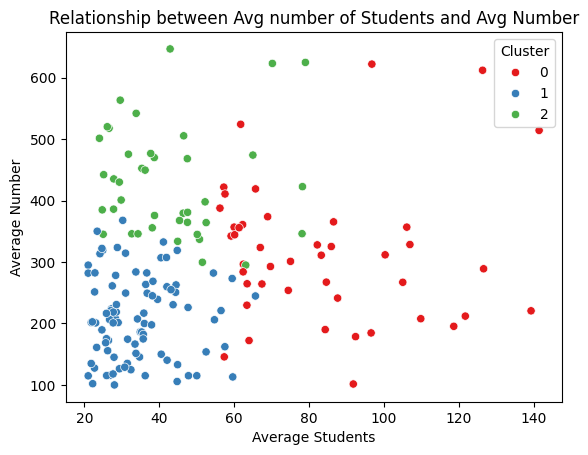

In [78]:
sns.scatterplot(
    data = df_subject,
    x = "Average Students",
    y = "Average Number",
    hue = "Cluster",
    palette = "Set1"
)
plt.title("Relationship between Avg number of Students and Avg Number")

#### Part 3.3.2 Boxplots

Using seaborn, create a boxplot for each of the 3 average columns we created earlier. Each plot should have one box for each cluster, we have given you the starter code for a seaborn boxplot. Since boxplots use only one column, we use only `y` to set equal to the column name. Make sure each plot has appropriate axis and title labels.

Text(0.5, 1.0, 'Box Plot of Average Number of Students')

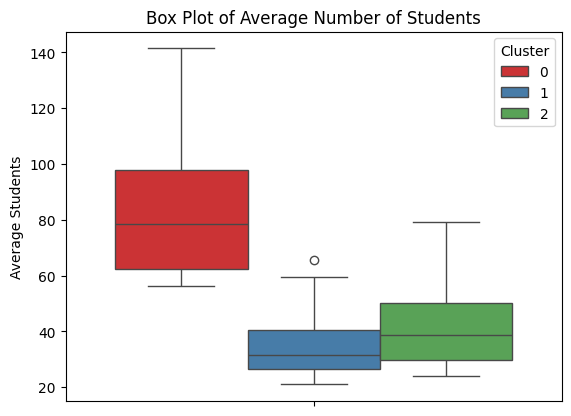

In [79]:
sns.boxplot(
    data = df_subject,
    y = "Average Students",
    hue = "Cluster",
    palette = "Set1"
)
plt.title("Box Plot of Average Number of Students")

Text(0.5, 1.0, 'Box Plot of Average Number')

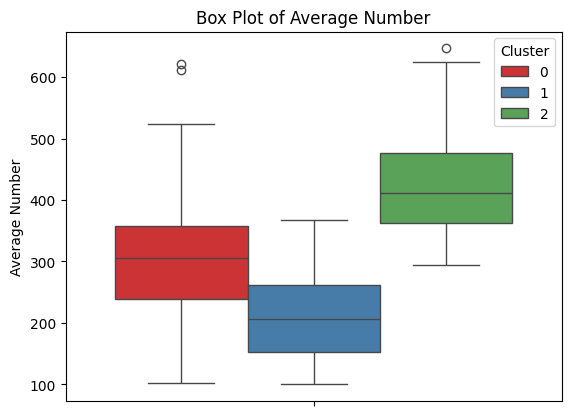

In [80]:
sns.boxplot(
    data = df_subject,
    y = "Average Number",
    hue = "Cluster",
    palette = "Set1"
)
plt.title("Box Plot of Average Number")

Text(0.5, 1.0, 'Box Plot of Average GPA')

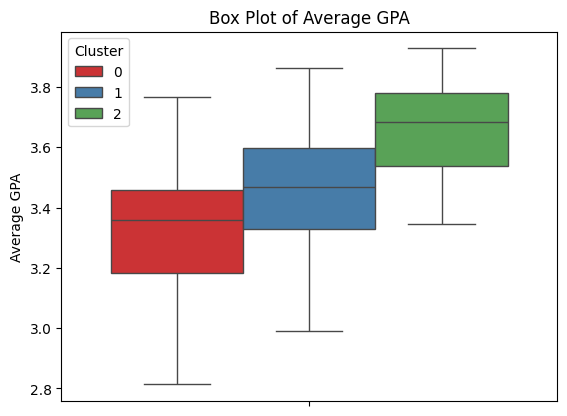

In [81]:
sns.boxplot(
    data = df_subject,
    y = "Average GPA",
    hue = "Cluster",
    palette = "Set1"
)
plt.title("Box Plot of Average GPA")

### Part 3.4: Centroids

Those are some beautiful plots! Now let's take a look at what each cluster actually represents by inspecting the centroids.

Create a dataframe `df_centroids` where each row is represents a cluster.

*Hint: Remember that each centroid is simply the average of the columns across every point in that `"Cluster"`.*

In [82]:
# Create df_centroids
df_centroids = df_subject.groupby("Cluster").agg("mean",numeric_only = True).reset_index()
df_centroids

,Cluster,Year,Number,A+,A,A-,B+,B,B-,C+,...,C-,D+,D,D-,F,W,Students,Average GPA,Average Number,Average Students
0,0,1.318734e+06,195741.386364,6662.045455,16764.363636,6343.136364,5045.090909,7027.886364,3123.363636,2243.659091,...,1292.522727,672.113636,917.045455,405.750000,1218.909091,234.227273,54701.136364,3.319061,312.696364,83.414659
1,1,5.822209e+05,63501.422222,1535.422222,3388.433333,1517.544444,1104.744444,1282.500000,581.077778,373.833333,...,194.133333,103.788889,131.322222,65.077778,246.388889,42.766667,10952.766667,3.471143,209.739293,34.257938
2,2,7.236961e+05,150860.100000,2444.375000,7078.225000,2804.100000,2065.100000,1949.525000,706.500000,357.100000,...,133.325000,51.475000,92.475000,27.150000,153.075000,41.725000,18216.025000,3.653106,429.916580,42.803981


You'll notice that this dataframe is pretty cluttered. Change it to only include the `"Cluster"` column and the three columns in `ind`.

*Hint: Remember that we use double brackets to select columns*

In [83]:
# Select a subset of columns from df_centroids
df_centroids = df_centroids[["Average GPA","Average Number","Average Students","Cluster"]]
df_centroids

,Average GPA,Average Number,Average Students,Cluster
0,3.319061,312.696364,83.414659,0
1,3.471143,209.739293,34.257938,1
2,3.653106,429.916580,42.803981,2


In [84]:
## == TEST CASES for Puzzle 3.4 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert 'df_centroids' in vars(), "Make sure to create the variable `df_centroids`"
assert len(df_centroids.columns) == 4, "Make sure to select a subset of columns from `df_centroids`"
assert set(df_centroids.columns) == {"Cluster", *ind}, "`df_centroids` does not have the right columns"

assert len(df_centroids) == 3, "`df_centroids` should have one row for each cluster"
assert set(df_centroids.Cluster) == {0, 1, 2}, "The \"Cluster\" column should contain the cluster number from 0 to 2"
for col in ind:
    m, sd = df_subject[col].mean(), df_subject[col].std()
    cc = kmeans.cluster_centers_[:,kmeans.feature_names_in_.tolist().index(col)]
    assert math.isclose(sum(cc*sd+m - df_centroids.sort_values("Cluster")[col]), 0, abs_tol = 1e-9), f"The cluster averages for the {col} column are incorrect"


## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Part 3.5: Your Major

As a final exploration, let's take a look at what cluster your major fell into!

Filter `df_subject` to your major and take a look at the predicted cluster. If you don't have a major yet, pick a subject that you're taking classes in this semester.

It should be clear from the output what your major's cluster is.

In [85]:
df_subject[df_subject.Subject == "FIN"]

,Subject,Year,Number,A+,A,A-,B+,B,B-,C+,...,D+,D,D-,F,W,Students,Average GPA,Average Number,Average Students,Cluster
74,FIN,3654166,721239,6435,35136,15086,11392,13519,4497,2241,...,520,845,87,933,266,94611,3.451173,398.034768,52.213576,2


### Analysis Questions

**Question 1**: Using the boxplots from part 3.3.2, compare the features of each cluster relative to the other clusters. Your answer should contain a sentence for each cluster comparing that cluster to the others.

**Question 2**: Using the cluster centroids in Part 3.4, look at the features of the centroid for your major. Do you agree with how your major was clustered? Explain your answer using numbers from the centroids.

Q1:
Cluster 0 shows the highest Average GPA and the highest Average Number, while its Average Students remains in a mid-range level.
Cluster 2 has the largest class sizes (Average Students) and the lowest GPA.
Cluster 1 has the smallest class sizes and the lowest course numbers, but its GPA falls in a moderate range.
Q2:
Based on the centroids, Cluster 0 students have the highest GPA (3.65) and the highest course numbers (436), which makes them appear to be the strongest group academically.
Cluster 2 shows the lowest GPA (3.31) along with the largest class sizes (77.8), suggesting that these subjects may be more crowded and less academically strong.

<hr style="color: #DD3403;">

# Submission

You're almost done!  All you need to do is to commit your lab to GitHub:

1.  ⚠️ **Make certain to save your work.** ⚠️ To do this, go to **File => Save All**

2.  After you have saved, exit this notebook and follow the Canvas instructions to commit this lab to your Git repository!

3. Your TA will grade your submission and provide you feedback after the lab is due. :)